LightGBM Model

1. Load Data 

In [134]:


import pandas as pd
import numpy as np
import lightgbm as lgb
from tqdm import tqdm
import gc
import sklearn

# Define file paths
file_paths = [
    "final_df_hourly2020.csv",
    "final_df_hourly2021.csv", 
    "final_df_hourly2022.csv",
    "final_df_hourly2023.csv"
]
test_path = "final_df_hourly2024.csv"

# Load training data in chunks
dfs = []
chunk_size = 500_000  # Adjust based on memory

for file in file_paths:
    for chunk in tqdm(pd.read_csv(file, chunksize=chunk_size), desc=f"Loading {file}"):
        dfs.append(chunk)

# Concatenate chunks into a single DataFrame
train_df = pd.concat(dfs, ignore_index=True)

# Load validation/test data
print(f"Loading {test_path}...")
test_df = pd.read_csv(test_path)
print(f"Loaded {test_path} successfully.")

# Memory optimization function - reducing data types (e.g., converting numerical columns to float32 or categorical columns to the category type)
def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024 ** 2
    print(f"Initial Memory Usage: {start_mem:.2f} MB")

    for col in df.columns:
        col_type = df[col].dtype

        if col_type == 'object':
            df[col] = df[col].astype('category')

        elif pd.api.types.is_numeric_dtype(col_type):
            if pd.api.types.is_float_dtype(col_type):
                df[col] = df[col].astype(np.float32)
            elif pd.api.types.is_integer_dtype(col_type):
                df[col] = pd.to_numeric(df[col], downcast='integer')

    end_mem = df.memory_usage().sum() / 1024 ** 2
    print(f"Final Memory Usage: {end_mem:.2f} MB")
    print(f"Memory reduction: {(start_mem - end_mem) / start_mem:.1%}")
    return df

# Apply optimization
train_df = reduce_mem_usage(train_df)
test_df = reduce_mem_usage(test_df)

# Data Summary
print("Data Summary Report")
print(f"Total rows in train_df: {len(train_df):,}")
print(f"Total rows in test_df: {len(test_df):,}")

# Free memory
del dfs
gc.collect()


Loading final_df_hourly2020.csv: 8it [00:02,  2.96it/s]
Loading final_df_hourly2021.csv: 9it [00:03,  2.77it/s]
Loading final_df_hourly2022.csv: 9it [00:03,  2.72it/s]
Loading final_df_hourly2023.csv: 9it [00:03,  2.74it/s]


Loading final_df_hourly2024.csv...
Loaded final_df_hourly2024.csv successfully.
Initial Memory Usage: 3418.41 MB
Final Memory Usage: 1607.63 MB
Memory reduction: 53.0%
Initial Memory Usage: 380.99 MB
Final Memory Usage: 182.54 MB
Memory reduction: 52.1%
Data Summary Report
Total rows in train_df: 16,518,255
Total rows in test_df: 1,841,014


61512

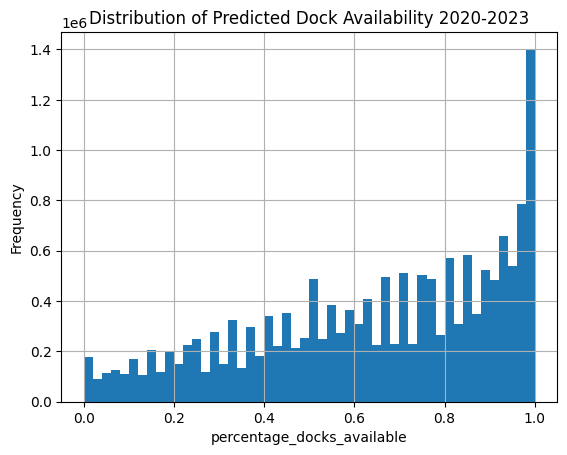

In [157]:
import matplotlib.pyplot as plt

plt.hist(train_df['percentage_docks_available'], bins=50)
plt.title("Distribution of Predicted Dock Availability 2020-2023")
plt.xlabel("percentage_docks_available")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

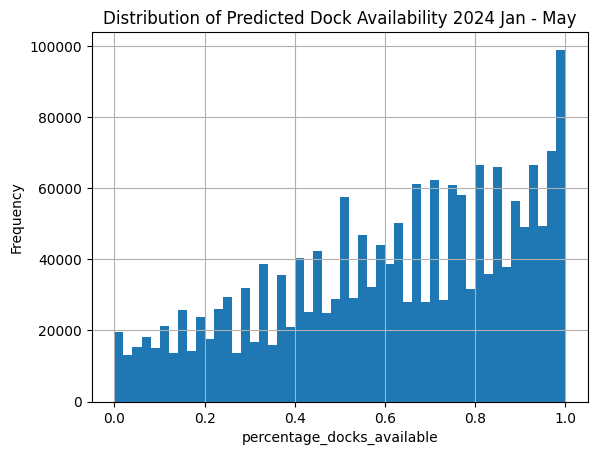

In [136]:
import matplotlib.pyplot as plt

plt.hist(test_df['percentage_docks_available'], bins=50)
plt.title("Distribution of Predicted Dock Availability 2024 Jan - May")
plt.xlabel("percentage_docks_available")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

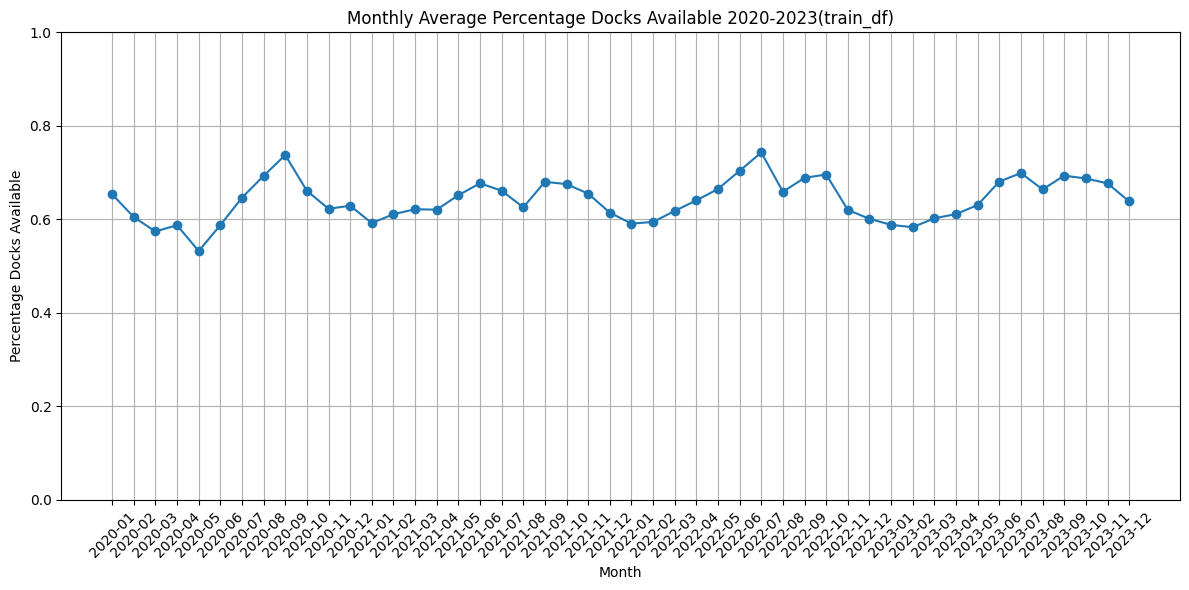

In [167]:
import matplotlib.pyplot as plt

# Group by year and month to get average availability
monthly_avg = train_df.groupby(['year', 'month_num'])['percentage_docks_available'].mean().reset_index()

# Create a combined time label for x-axis
monthly_avg['month_label'] = monthly_avg['year'].astype(str) + '-' + monthly_avg['month_num'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['month_label'], monthly_avg['percentage_docks_available'], marker='o')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Monthly Average Percentage Docks Available 2020-2023(train_df)")
plt.xlabel("Month")
plt.ylabel("Percentage Docks Available")
plt.grid(True)
plt.tight_layout()
plt.show()


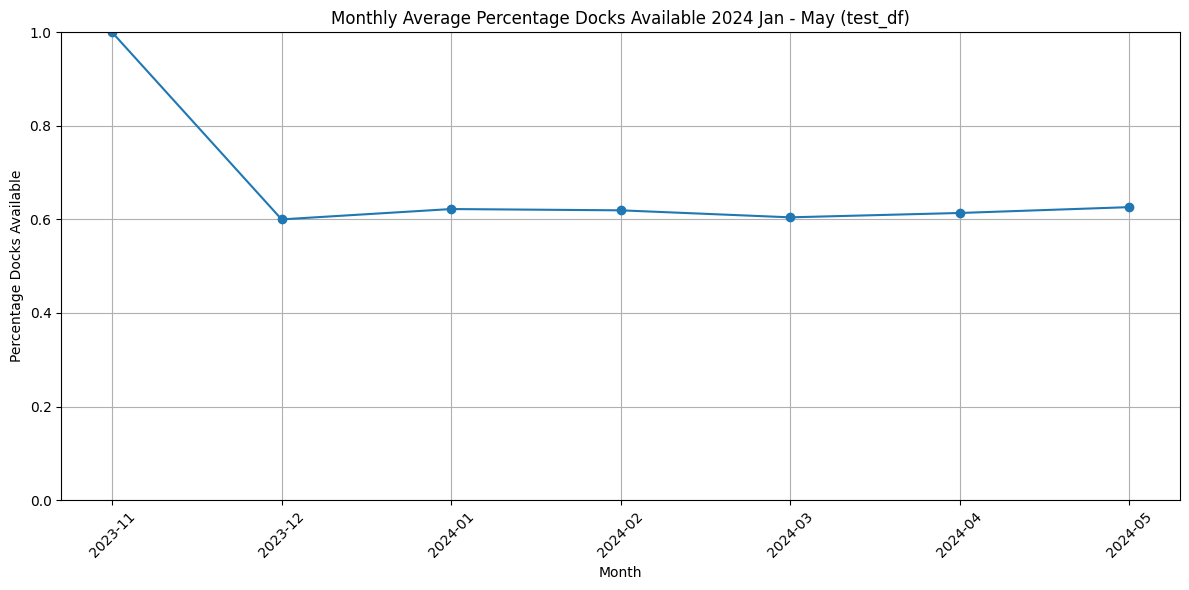

In [168]:
# Group by year and month to get average availability
monthly_avg = test_df.groupby(['year', 'month_num'])['percentage_docks_available'].mean().reset_index()

# Create a combined time label for x-axis
monthly_avg['month_label'] = monthly_avg['year'].astype(str) + '-' + monthly_avg['month_num'].astype(str).str.zfill(2)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['month_label'], monthly_avg['percentage_docks_available'], marker='o')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Monthly Average Percentage Docks Available 2024 Jan - May (test_df)")
plt.xlabel("Month")
plt.ylabel("Percentage Docks Available")
plt.grid(True)
plt.tight_layout()
plt.show()

1.1. Analyse the data 

In [137]:
# Display first few rows
display(train_df.head())
display(test_df.head())

# Check data types
print("Data Types in train_df:")
print(train_df.dtypes)

print("Data Types in test_df:")
print(test_df.dtypes)


,station_id,num_bikes_available,num_bikes_available_types.mechanical,num_bikes_available_types.ebike,num_docks_available,is_installed,is_renting,is_returning,last_reported,is_charging_station,...,year,day_of_month,capacity,percentage_docks_available,temperature,raining,feels_like_weather,humidity,wind_speed,sunshine
0,1.0,23.0,23.0,0.0,21.0,1.0,1.0,1.0,2020-01-01 00:02:22,True,...,2020,1,46,0.500000,4.64,0.0,1.536496,85.641792,9.504273,0.0
1,1.0,24.0,23.0,1.0,20.0,1.0,1.0,1.0,2020-01-01 01:04:02,True,...,2020,1,46,0.478261,4.24,0.0,0.874873,87.136894,11.113451,0.0
2,1.0,26.0,24.0,2.0,18.0,1.0,1.0,1.0,2020-01-01 02:01:19,True,...,2020,1,46,0.434783,3.69,0.0,0.518975,89.924957,9.659814,0.0
3,1.0,31.0,29.0,2.0,13.0,1.0,1.0,1.0,2020-01-01 03:02:51,True,...,2020,1,46,0.326087,3.29,0.0,0.066232,90.538269,9.659814,0.0
4,1.0,27.0,26.0,1.0,17.0,1.0,1.0,1.0,2020-01-01 04:04:23,True,...,2020,1,46,0.413043,2.79,0.0,-0.455314,92.136627,9.511088,0.0


,station_id,num_bikes_available,num_bikes_available_types.mechanical,num_bikes_available_types.ebike,num_docks_available,last_reported,is_charging_station,status,is_installed,is_renting,...,year,day_of_month,capacity,percentage_docks_available,temperature,raining,feels_like_weather,humidity,wind_speed,sunshine
0,1.0,12.0,2.0,10.0,33.0,2023-12-31 22:58:59,True,IN_SERVICE,1.0,1.0,...,2023,31,46,0.739130,6.39,0.0,4.131680,81.996552,5.116561,0.0
1,1.0,12.0,2.0,10.0,33.0,2023-12-31 23:03:23,True,IN_SERVICE,1.0,1.0,...,2023,31,46,0.739130,5.74,0.0,3.713239,85.157227,3.396233,0.0
2,1.0,11.0,4.0,7.0,34.0,2024-01-01 00:00:51,True,IN_SERVICE,1.0,1.0,...,2024,1,46,0.760870,5.49,0.0,3.369489,86.950951,4.104631,0.0
3,1.0,9.0,4.0,5.0,36.0,2024-01-01 01:03:02,True,IN_SERVICE,1.0,1.0,...,2024,1,46,0.804348,5.24,0.0,2.635364,91.962143,8.161764,0.0
4,1.0,12.0,4.0,8.0,33.0,2024-01-01 02:04:50,True,IN_SERVICE,1.0,1.0,...,2024,1,46,0.739130,5.44,0.0,3.061213,89.743782,6.409617,0.0


Data Types in train_df:
station_id                               float32
num_bikes_available                      float32
num_bikes_available_types.mechanical     float32
num_bikes_available_types.ebike          float32
num_docks_available                      float32
is_installed                             float32
is_renting                               float32
is_returning                             float32
last_reported                           category
is_charging_station                         bool
status                                  category
ttl                                      float32
date                                    category
hour                                        int8
weekday                                 category
weekday_num                                 int8
month                                   category
month_num                                   int8
year                                       int16
day_of_month                                i

1.2. Reduce the df to the relevant fields for machine learning

In [138]:
# Define the required columns
required_columns = [
    "station_id", "last_reported", "hour", "day_of_month", "month_num", "year", "weekday_num",
    "temperature", "feels_like_weather","raining", "humidity", "wind_speed", "sunshine", 
    "num_bikes_available", "num_docks_available", "percentage_docks_available"
]

# Reduce train_df and test_df
train_df = train_df[required_columns]
test_df = test_df[required_columns]

# Display shape of new DataFrames
print(f"Reduced train_df shape: {train_df.shape}")
print(f"Reduced test_df shape: {test_df.shape}")

# Display first few rows to confirm
print("\nTrain Data Preview:")
display(train_df.head())

print("\nTest Data Preview:")
display(test_df.head())


Reduced train_df shape: (16518255, 16)
Reduced test_df shape: (1841014, 16)

Train Data Preview:


,station_id,last_reported,hour,day_of_month,month_num,year,weekday_num,temperature,feels_like_weather,raining,humidity,wind_speed,sunshine,num_bikes_available,num_docks_available,percentage_docks_available
0,1.0,2020-01-01 00:02:22,0,1,1,2020,3,4.64,1.536496,0.0,85.641792,9.504273,0.0,23.0,21.0,0.500000
1,1.0,2020-01-01 01:04:02,1,1,1,2020,3,4.24,0.874873,0.0,87.136894,11.113451,0.0,24.0,20.0,0.478261
2,1.0,2020-01-01 02:01:19,2,1,1,2020,3,3.69,0.518975,0.0,89.924957,9.659814,0.0,26.0,18.0,0.434783
3,1.0,2020-01-01 03:02:51,3,1,1,2020,3,3.29,0.066232,0.0,90.538269,9.659814,0.0,31.0,13.0,0.326087
4,1.0,2020-01-01 04:04:23,4,1,1,2020,3,2.79,-0.455314,0.0,92.136627,9.511088,0.0,27.0,17.0,0.413043



Test Data Preview:


,station_id,last_reported,hour,day_of_month,month_num,year,weekday_num,temperature,feels_like_weather,raining,humidity,wind_speed,sunshine,num_bikes_available,num_docks_available,percentage_docks_available
0,1.0,2023-12-31 22:58:59,22,31,12,2023,7,6.39,4.131680,0.0,81.996552,5.116561,0.0,12.0,33.0,0.739130
1,1.0,2023-12-31 23:03:23,23,31,12,2023,7,5.74,3.713239,0.0,85.157227,3.396233,0.0,12.0,33.0,0.739130
2,1.0,2024-01-01 00:00:51,0,1,1,2024,1,5.49,3.369489,0.0,86.950951,4.104631,0.0,11.0,34.0,0.760870
3,1.0,2024-01-01 01:03:02,1,1,1,2024,1,5.24,2.635364,0.0,91.962143,8.161764,0.0,9.0,36.0,0.804348
4,1.0,2024-01-01 02:04:50,2,1,1,2024,1,5.44,3.061213,0.0,89.743782,6.409617,0.0,12.0,33.0,0.739130


2.4 ACF and PACF (AutoCorrelation Function and Partial ACF) analysis, both at the hourly and daily levels.

In [139]:
# Convert 'last_reported' to datetime
train_df['last_reported'] = pd.to_datetime(train_df['last_reported'])
test_df['last_reported'] = pd.to_datetime(test_df['last_reported'])

# Set 'last_reported' as index
train_df.set_index('last_reported', inplace=True)
test_df.set_index('last_reported', inplace=True)

# Confirm changes
print("Index set to datetime successfully.")
print("\nTrain index preview:", train_df.index[:5])
print("Test index preview:", test_df.index[:5])



Index set to datetime successfully.

Train index preview: DatetimeIndex(['2020-01-01 00:02:22', '2020-01-01 01:04:02',
               '2020-01-01 02:01:19', '2020-01-01 03:02:51',
               '2020-01-01 04:04:23'],
              dtype='datetime64[ns]', name='last_reported', freq=None)
Test index preview: DatetimeIndex(['2023-12-31 22:58:59', '2023-12-31 23:03:23',
               '2024-01-01 00:00:51', '2024-01-01 01:03:02',
               '2024-01-01 02:04:50'],
              dtype='datetime64[ns]', name='last_reported', freq=None)


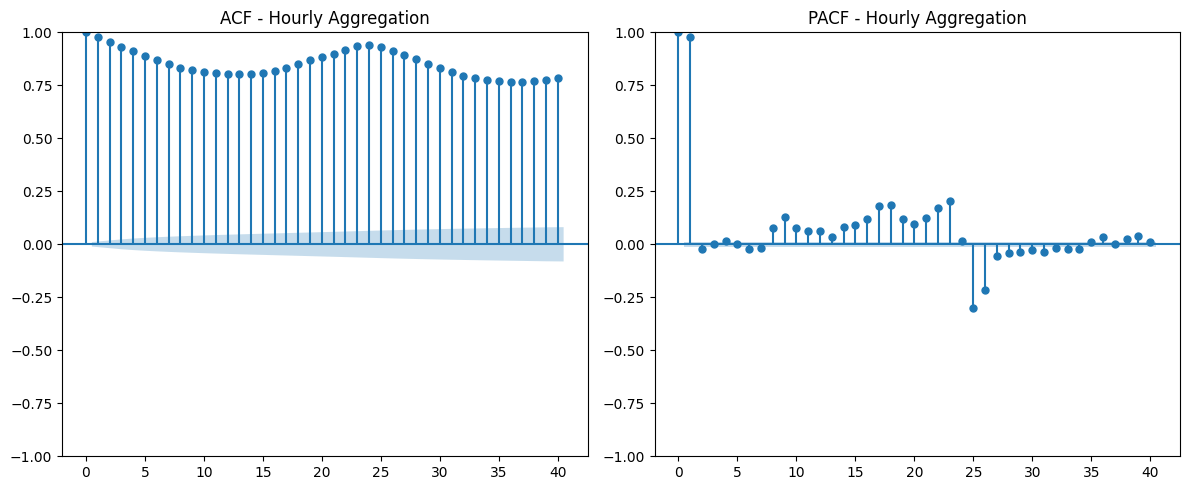

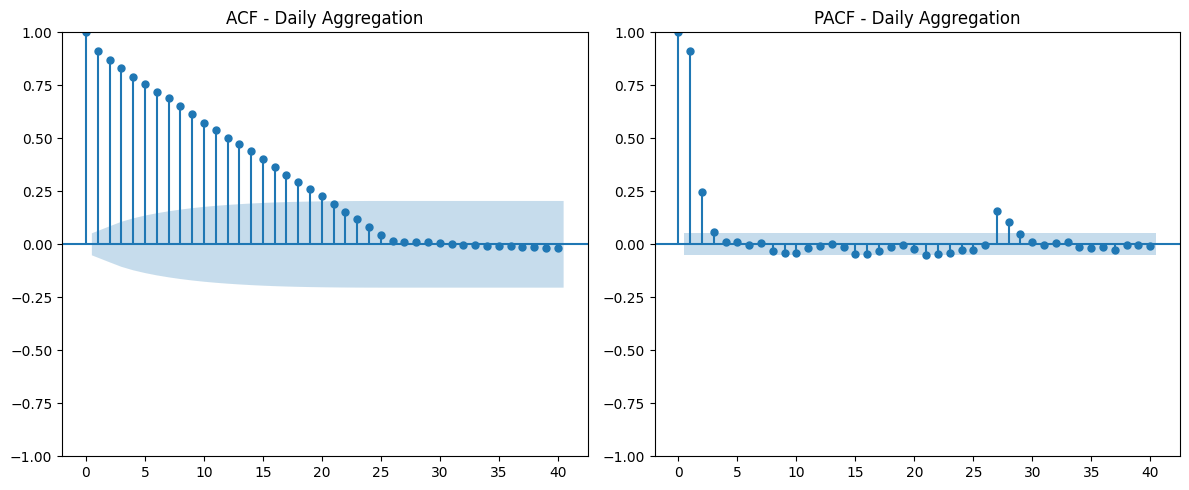

<Figure size 640x480 with 0 Axes>

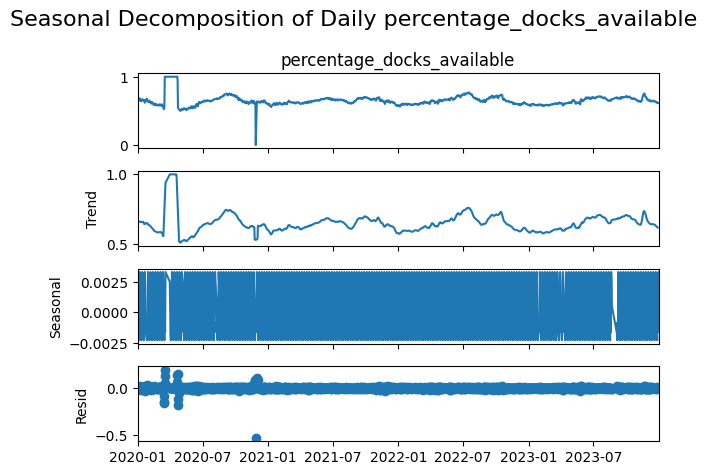

<Figure size 640x480 with 0 Axes>

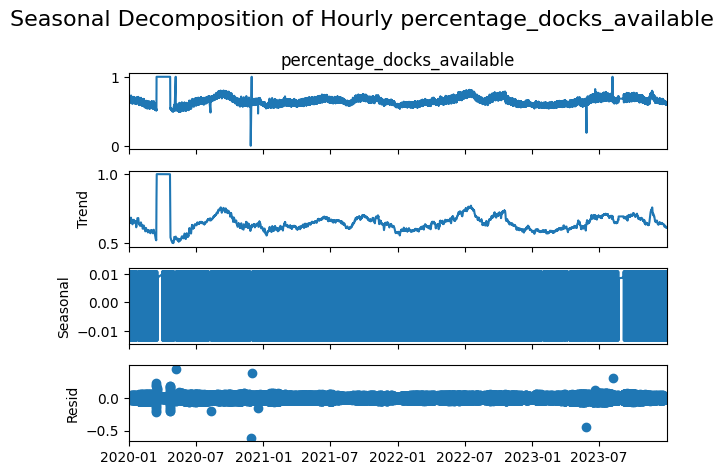

In [140]:

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to hourly and daily
hourly_series = train_df['percentage_docks_available'].resample('h').mean()
daily_series = train_df['percentage_docks_available'].resample('D').mean()

# Function to plot ACF and PACF
def plot_acf_pacf(series, title, lags=40):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plot_acf(series.dropna(), ax=plt.gca(), lags=lags)
    plt.title(f"ACF - {title}")
    
    plt.subplot(1,2,2)
    plot_pacf(series.dropna(), ax=plt.gca(), lags=lags, method='ywm')
    plt.title(f"PACF - {title}")
    
    plt.tight_layout()
    plt.show()

# Plot ACF & PACF for hourly
plot_acf_pacf(hourly_series, "Hourly Aggregation")

# Plot ACF & PACF for daily
plot_acf_pacf(daily_series, "Daily Aggregation")

# --- Seasonal Decomposition ---

# Daily decomposition (period=7 for weekly seasonality)
daily_clean = daily_series.dropna()
decomp_daily = seasonal_decompose(daily_clean, model='additive', period=7)

plt.figure()
decomp_daily.plot()
plt.suptitle("Seasonal Decomposition of Daily percentage_docks_available", fontsize=16)
plt.tight_layout()
plt.show()

# Hourly decomposition (period=24 for daily seasonality)
hourly_clean = hourly_series.dropna()
decomp_hourly = seasonal_decompose(hourly_clean, model='additive', period=24)

plt.figure()
decomp_hourly.plot()
plt.suptitle("Seasonal Decomposition of Hourly percentage_docks_available", fontsize=16)
plt.tight_layout()
plt.show()


2. Create new Features and optimize

In [141]:
import pandas as pd
import numpy as np

# Step 1: Sort and set index
if 'last_reported' in train_df.columns:
    train_df = train_df.sort_values(by='last_reported')
    train_df.set_index('last_reported', inplace=True)

if 'last_reported' in test_df.columns:
    test_df = test_df.sort_values(by='last_reported')
    test_df.set_index('last_reported', inplace=True)

# Step 2: Define Feature Engineering
def feature_engineering(df):
    # Lag features
    for i in range(1, 5):
        df[f'ctx-{i}'] = df['percentage_docks_available'].shift(i)

    # Rolling statistics
    #df['rolling_mean_4h'] = df['percentage_docks_available'].rolling(window=4).mean()
    #df['rolling_std_4h'] = df['percentage_docks_available'].rolling(window=4).std()

    # Time-based features
    df['hour'] = df.index.hour
    df['day'] = df.index.day
    df['month'] = df.index.month
    df['weekday_num'] = df.index.weekday
    df['is_weekend'] = (df['weekday_num'] >= 5).astype(int)

    # Remove NaNs from shift/rolling
    df.dropna(inplace=True)

    return df

# Step 3: Apply to train and test
train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

# Step 4: Confirm
print("Train Data Preview:")
print(train_df.head())
print("Test Data Preview:")
print(test_df.head())



Train Data Preview:
                     station_id  hour  day_of_month  month_num  year  \
last_reported                                                          
2020-01-01 04:04:23         1.0     4             1          1  2020   
2020-01-01 05:01:24         1.0     5             1          1  2020   
2020-01-01 06:02:46         1.0     6             1          1  2020   
2020-01-01 07:04:13         1.0     7             1          1  2020   
2020-01-01 08:01:12         1.0     8             1          1  2020   

                     weekday_num  temperature  feels_like_weather  raining  \
last_reported                                                                
2020-01-01 04:04:23            2         2.79           -0.455314      0.0   
2020-01-01 05:01:24            2         2.49           -0.822053      0.0   
2020-01-01 06:02:46            2         2.54           -0.912044      0.0   
2020-01-01 07:04:13            2         2.54           -1.072822      0.0   
2020-01

In [142]:
display(train_df.head())

display(test_df.head())

,station_id,hour,day_of_month,month_num,year,weekday_num,temperature,feels_like_weather,raining,humidity,...,num_bikes_available,num_docks_available,percentage_docks_available,ctx-1,ctx-2,ctx-3,ctx-4,day,month,is_weekend
last_reported,,,,,,,,,,,,,,,,,,,,,
2020-01-01 04:04:23,1.0,4,1,1,2020,2,2.79,-0.455314,0.0,92.136627,...,27.0,17.0,0.413043,0.326087,0.434783,0.478261,0.500000,1,1,0
2020-01-01 05:01:24,1.0,5,1,1,2020,2,2.49,-0.822053,0.0,93.113953,...,28.0,16.0,0.391304,0.413043,0.326087,0.434783,0.478261,1,1,0
2020-01-01 06:02:46,1.0,6,1,1,2020,2,2.54,-0.912044,0.0,91.135208,...,33.0,11.0,0.282609,0.391304,0.413043,0.326087,0.434783,1,1,0
2020-01-01 07:04:13,1.0,7,1,1,2020,2,2.54,-1.072822,0.0,87.599358,...,33.0,11.0,0.282609,0.282609,0.391304,0.413043,0.326087,1,1,0
2020-01-01 08:01:12,1.0,8,1,1,2020,2,2.64,-0.975196,0.0,85.424088,...,33.0,11.0,0.282609,0.282609,0.282609,0.391304,0.413043,1,1,0


,station_id,hour,day_of_month,month_num,year,weekday_num,temperature,feels_like_weather,raining,humidity,...,num_bikes_available,num_docks_available,percentage_docks_available,ctx-1,ctx-2,ctx-3,ctx-4,day,month,is_weekend
last_reported,,,,,,,,,,,,,,,,,,,,,
2024-01-01 02:04:50,1.0,2,1,1,2024,0,5.44,3.061213,0.0,89.743782,...,12.0,33.0,0.739130,0.804348,0.760870,0.739130,0.739130,1,1,0
2024-01-01 03:02:18,1.0,3,1,1,2024,0,5.74,3.242599,0.0,83.667793,...,17.0,28.0,0.630435,0.739130,0.804348,0.760870,0.739130,1,1,0
2024-01-01 04:04:05,1.0,4,1,1,2024,0,6.14,3.505898,0.0,77.174034,...,13.0,32.0,0.717391,0.630435,0.739130,0.804348,0.760870,1,1,0
2024-01-01 05:01:16,1.0,5,1,1,2024,0,5.69,3.093650,0.0,80.179672,...,12.0,33.0,0.739130,0.717391,0.630435,0.739130,0.804348,1,1,0
2024-01-01 06:07:27,1.0,6,1,1,2024,0,4.64,1.953550,0.0,86.559288,...,12.0,33.0,0.739130,0.739130,0.717391,0.630435,0.739130,1,1,0


In [143]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Annual and monthly average of rolling_std_4h
#annual_std = train_df['rolling_std_4h'].resample('YE').mean()
#monthly_std = train_df['rolling_std_4h'].resample('ME').mean()

# Plot annual rolling_std_4h
#plt.figure(figsize=(12, 6))
#annual_std.plot(marker='o')
#plt.title('Annual Average of rolling_std_4h')
#plt.xlabel('Year')
#plt.ylabel('Average rolling_std_4h')
#plt.grid(True)
#plt.show()

# Plot monthly rolling_std_4h
#plt.figure(figsize=(14, 7))
#monthly_std.plot(marker='.', linestyle='-', alpha=0.8)
#plt.title('Monthly Average of rolling_std_4h (2020-2023)')
#plt.xlabel('Month')
#plt.ylabel('Average rolling_std_4h')
#plt.grid(True)
#plt.show()

# Distribution of rolling_std_4h
#plt.figure(figsize=(10, 5))
#sns.histplot(train_df['rolling_std_4h'].dropna(), bins=50, kde=True)
#plt.title('Distribution of rolling_std_4h')
#plt.xlabel('rolling_std_4h')
#plt.ylabel('Frequency')
#plt.grid(True)
#plt.show()

# Bring back 'last_reported' as a column
train_df["last_reported"] = train_df.index

# Reset index (creating a numeric index again)
train_df.reset_index(drop=True, inplace=True)


2.1. Optimize with Optuna

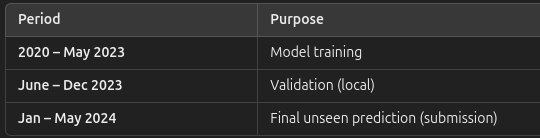

Limiting training to these features based on the previous analysis

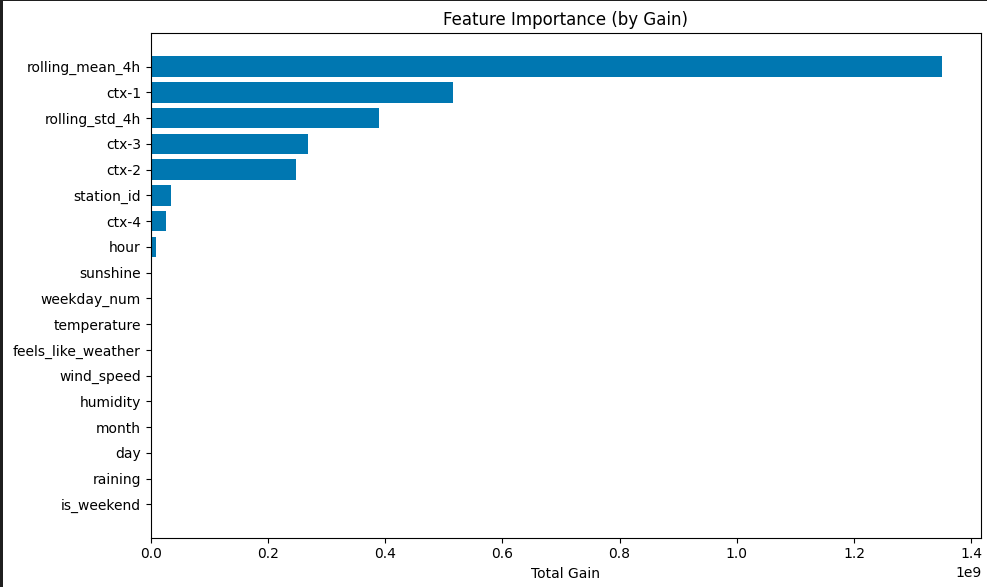

Metafile features
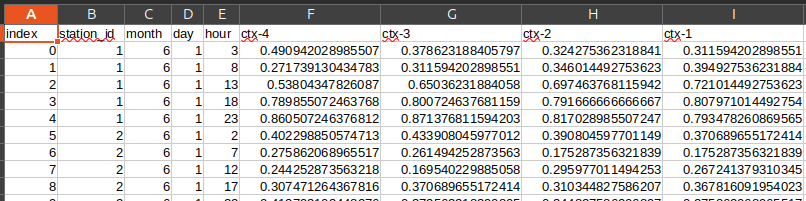

In [144]:
import lightgbm as lgb
import optuna
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error


import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Ensure dataset is sorted (important for time series)
train_df = train_df.sort_values(by="last_reported")
test_df = test_df.sort_values(by="last_reported")

# Split train_df into training and validation subsets
train_cutoff = "2023-06-01"
val_cutoff = "2024-01-01"

train_subset = train_df[train_df["last_reported"] < train_cutoff]
val_subset = train_df[(train_df["last_reported"] >= train_cutoff) & (train_df["last_reported"] < val_cutoff)]



# Feature list
FEATURES = [
    "ctx-4", "ctx-3", "ctx-2", "ctx-1",
    "hour", "month" ,"day", 
    "station_id", 
]

TARGET = "percentage_docks_available"

# Split features and targets
X_train = train_subset[FEATURES]
y_train = train_subset[TARGET]

X_valid = val_subset[FEATURES]
y_valid = val_subset[TARGET]

# Final prediction data (used after tuning)
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# Categorical conversion
for cat_col in ["station_id"]:
    X_train.loc[:, cat_col] = X_train[cat_col].astype(int).astype("category")
    X_valid.loc[:, cat_col] = X_valid[cat_col].astype(int).astype("category")
    X_test.loc[:, cat_col] = X_test[cat_col].astype(int).astype("category")

# Check data integrity
print(f"X_train: {X_train.shape}, X_valid: {X_valid.shape}, X_test: {X_test.shape}")
print(f"Missing in X_train:\n{X_train.isnull().sum()}")
print(f"Missing in X_valid:\n{X_valid.isnull().sum()}")



# Optuna tuning function
from scipy.special import logit, expit

def objective(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 50, 150),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "n_estimators": trial.suggest_int("n_estimators", 200, 3000),
        "min_child_samples": trial.suggest_int("min_child_samples", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 1.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 1.0, log=True),
        "max_bin": trial.suggest_int("max_bin", 255, 500),
        "random_state": 42
    }

    model = lgb.LGBMRegressor(**params)

    # Apply logit transform and clipping
    y_train_logit = logit(y_train.clip(1e-6, 1 - 1e-6))
    y_valid_logit = logit(y_valid.clip(1e-6, 1 - 1e-6))

    model.fit(
        X_train, y_train_logit,
        eval_set=[(X_valid, y_valid_logit)],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(100)
        ]
    )

    preds_logit = model.predict(X_valid)
    preds = expit(preds_logit)  # Convert predictions back to original scale [0,1]

    rmse = mean_squared_error(y_valid, preds) ** 0.5
    return rmse


# Trial tracking
def trial_callback(study, trial):
    print(f"🔥 Trial {len(study.trials)} - RMSE: {trial.value:.4f}")

# Run Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=5,callbacks=[trial_callback], show_progress_bar=True)       # timeout=600, 

print("🎯 Best Hyperparameters:", study.best_params)

import json

# Save best parameters to a JSON file
with open("best_params.json", "w") as f:
    json.dump(study.best_params, f)

print("Best parameters saved to best_params.json")


/tmp/ipykernel_278931/193217907.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[22, 95, 117, 364, 46, ..., 15, 406, 463, 233, 246]
Length: 14103930
Categories (519, int64): [1, 2, 3, 4, ..., 527, 529, 530, 532]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_train.loc[:, cat_col] = X_train[cat_col].astype(int).astype("category")
/tmp/ipykernel_278931/193217907.py:47: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[294, 460, 217, 3, 353, ..., 274, 495, 260, 95, 94]
Length: 2414321
Categories (511, int64): [1, 2, 3, 4, ..., 517, 518, 519, 520]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  X_valid.loc[:, cat_col] = X_valid[cat_col].astype(int).astype("category")
/tmp/ipykernel_278931/193217907.py:48: FutureWarning: Setting an item of incompatible dtype

X_train: (14103930, 8), X_valid: (2414321, 8), X_test: (1841010, 8)
Missing in X_train:
ctx-4         0
ctx-3         0
ctx-2         0
ctx-1         0
hour          0
month         0
day           0
station_id    0
dtype: int64
Missing in X_valid:
ctx-4         0
ctx-3         0
ctx-2         0
ctx-1         0
hour          0
month         0
day           0
station_id    0
dtype: int64


  0%|          | 0/5 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=0.49840402424122726, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.49840402424122726
[LightGBM] [Warning] lambda_l1 is set=0.00037980132187666744, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00037980132187666744
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] lambda_l2 is set=0.49840402424122726, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.49840402424122726
[LightGBM] [Warning] lambda_l1 is set=0.00037980132187666744, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.00037980132187666744
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041755 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_w

2.3. Load the best hyperparameters from Jason if needed

In [145]:
# Load best parameters from the JSON file
# with open("best_params.json", "r") as f:
    # best_params = json.load(f)

# print("Loaded best parameters:", best_params)


3. Train LightGBM Model

Training Progress:   0%|                                                   | 0/2228 [00:00<?, ?it/s]

[LightGBM] [Warning] lambda_l2 is set=0.2254048146256481, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.2254048146256481
[LightGBM] [Warning] lambda_l1 is set=0.025407959044948067, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.025407959044948067
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] lambda_l2 is set=0.2254048146256481, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.2254048146256481
[LightGBM] [Warning] lambda_l1 is set=0.025407959044948067, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.025407959044948067
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.053159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[

Training Progress: 100%|████████████████████████████████████████| 2228/2228 [04:06<00:00,  9.04it/s]


Final model trained and saved.


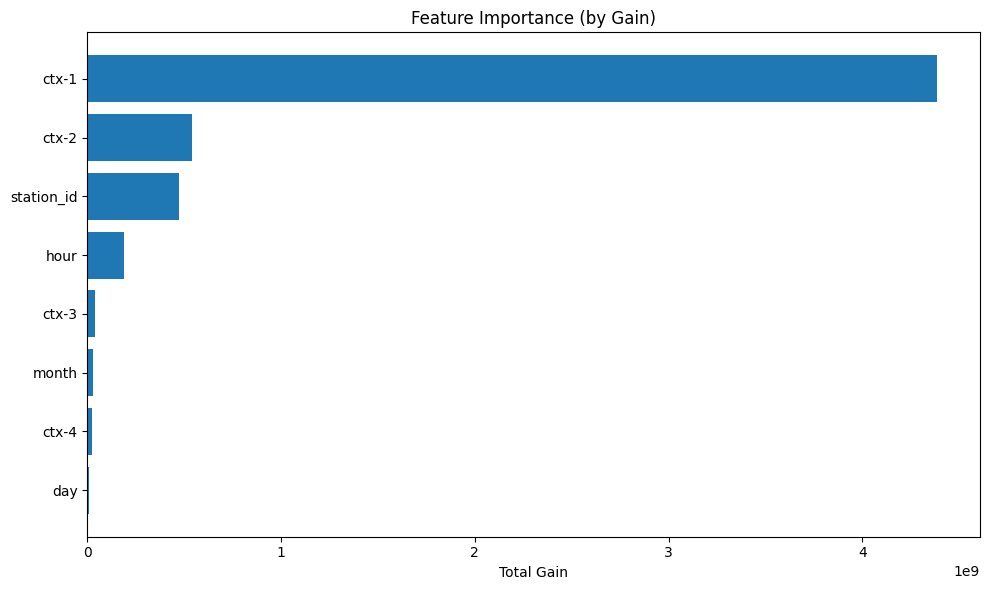

In [146]:
from lightgbm import LGBMRegressor, log_evaluation
import joblib
import json
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from scipy.special import logit, expit
from sklearn.metrics import mean_squared_error
import numpy as np

# Load best params
with open("best_params.json", "r") as f:
    best_params = json.load(f)

# Ensure categorical features are set correctly
for cat_col in ["station_id"]:
    train_df[cat_col] = train_df[cat_col].astype(int).astype("category")
    test_df[cat_col] = test_df[cat_col].astype(int).astype("category")

# Features and target
X_full = train_df[FEATURES].copy()
y_full_raw = train_df[TARGET]

X_test = test_df[FEATURES].copy()
y_test_raw = test_df[TARGET]

# Apply logit transform (training data)
y_full_logit = logit(y_full_raw.clip(1e-6, 1 - 1e-6))

# Progress bar setup
n_estimators = best_params.get("n_estimators", 100)
pbar = tqdm(total=n_estimators, desc="Training Progress", ncols=100)

def tqdm_callback(env):
    pbar.update(1)

# Train model
final_model = LGBMRegressor(**best_params)
final_model.fit(
    X_full, y_full_logit,
    callbacks=[log_evaluation(period=100), tqdm_callback]
)

pbar.close()

# Save trained model
joblib.dump(final_model, "final_model_lgbm.pkl")
print("Final model trained and saved.")

# Feature Importance Plot
importance = final_model.booster_.feature_importance(importance_type="gain")
features = final_model.booster_.feature_name()

importances_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_df["Feature"], importances_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (by Gain)")
plt.xlabel("Total Gain")
plt.tight_layout()
plt.show()


4. Evaluate the model

In [147]:
display(X_test)

,ctx-4,ctx-3,ctx-2,ctx-1,hour,month,day,station_id
last_reported,,,,,,,,
2023-11-03 06:59:06,0.629630,0.629630,0.518519,0.259259,6,11,3,234
2023-11-27 07:23:13,0.150000,0.100000,0.100000,0.100000,7,11,27,37
2023-12-31 22:47:15,0.958333,0.875000,0.916667,1.000000,22,12,31,495
2023-12-31 22:53:14,0.777778,1.000000,0.666667,0.666667,22,12,31,27
2023-12-31 22:54:34,0.888889,0.962963,0.888889,0.592593,22,12,31,435
...,...,...,...,...,...,...,...,...
2024-05-31 22:05:03,0.575758,0.424242,0.787879,0.787879,22,5,31,182
2024-05-31 22:05:03,0.562500,0.500000,0.593750,0.562500,22,5,31,141
2024-05-31 22:05:03,0.111111,0.259259,0.666667,0.555556,22,5,31,245


Evaluate with Test data 2024 Jan-May

In [148]:
X_test = test_df[FEATURES]
y_test = test_df[TARGET]

# ===== Important Correction Here =====
# Predictions on test set
y_test_pred_logit = final_model.predict(X_test)

# Apply inverse-logit transformation (expit)
y_test_pred = expit(y_test_pred_logit)

# Clip predictions explicitly (optional but safe)
y_test_pred = np.clip(y_test_pred, 0, 1)

# Evaluate performance clearly
# RMSE calculation explicitly
test_rmse = mean_squared_error(y_test_raw, y_test_pred) ** 0.5
print(f"✅ Final Test RMSE: {test_rmse:.4f}")



[LightGBM] [Warning] lambda_l2 is set=0.2254048146256481, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.2254048146256481
[LightGBM] [Warning] lambda_l1 is set=0.025407959044948067, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.025407959044948067
✅ Final Test RMSE: 0.1434


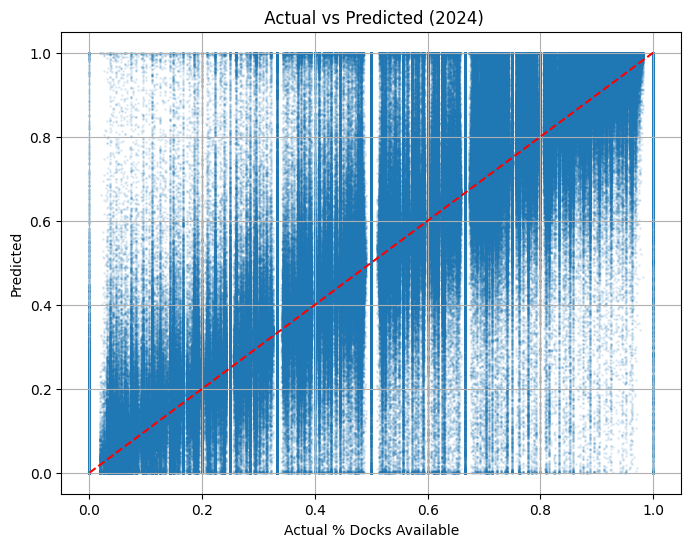

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test_raw, y_test_pred, alpha=0.1, s=1)
plt.xlabel("Actual % Docks Available")
plt.ylabel("Predicted")
plt.title(" Actual vs Predicted (2024)")
plt.plot([0, 1], [0, 1], 'r--')
plt.grid(True)
plt.show()


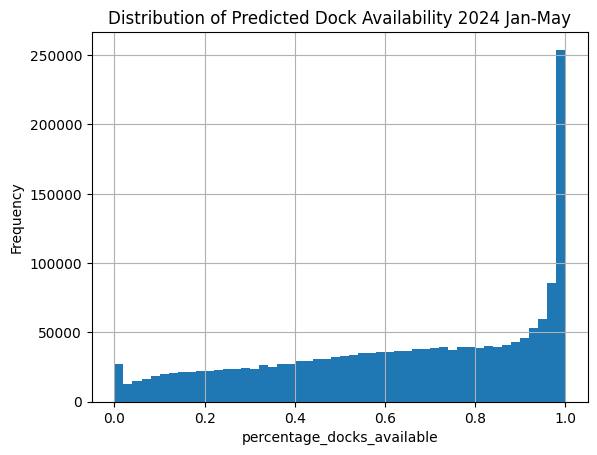

In [150]:
import matplotlib.pyplot as plt

plt.hist(y_test_pred, bins=50)
plt.title("Distribution of Predicted Dock Availability 2024 Jan-May")
plt.xlabel("percentage_docks_available")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


5. Prepare Kaggle Submission

5.1. Load metadata_sample_submission_2025.csv

5.2. Prepare the meta file

In [151]:
import pandas as pd
import joblib
from scipy.special import expit

# Load your submission metadata
submission_df = pd.read_csv("metadata_sample_submission_2025.csv")

# Data type conversions
submission_df['station_id'] = submission_df['station_id'].astype('category')
submission_df['hour'] = submission_df['hour'].astype('int32')
submission_df['day'] = submission_df['day'].astype('int32')
submission_df['month'] = submission_df['month'].astype('int32')

# Convert ctx-* columns to float32
for ctx_col in ['ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']:
    submission_df[ctx_col] = submission_df[ctx_col].astype('float32')

# Feature engineering (rolling statistics)
#submission_df['rolling_mean_4h'] = submission_df[['ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']].mean(axis=1)
#submission_df['rolling_std_4h'] = submission_df[['ctx-1', 'ctx-2', 'ctx-3', 'ctx-4']].std(axis=1)

# Ensure FEATURES list matches exactly training                                 
# FEATURES = [
    # "ctx-4", "ctx-3", "ctx-2", "ctx-1",                    
    "# hour", "day", "month", "station_id",
# ]

# ,"rolling_mean_4h", "rolling_std_4h"

# Load trained model
model = joblib.load("final_model_lgbm.pkl")

# Make predictions and inverse-logit transform them
submission_df['percentage_docks_available'] = expit(model.predict(submission_df[FEATURES]))

# Ensure final predictions are within [0, 1]
submission_df['percentage_docks_available'] = submission_df['percentage_docks_available'].clip(0, 1)



[LightGBM] [Warning] lambda_l2 is set=0.2254048146256481, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.2254048146256481
[LightGBM] [Warning] lambda_l1 is set=0.025407959044948067, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.025407959044948067


,index,station_id,month,day,hour,ctx-4,ctx-3,ctx-2,ctx-1,percentage_docks_available
0,0,1,6,1,3,0.490942,0.378623,0.324275,0.311594,0.323297
1,1,1,6,1,8,0.271739,0.311594,0.346014,0.394928,0.459513
2,2,1,6,1,13,0.538043,0.650362,0.697464,0.721014,0.776674
3,3,1,6,1,18,0.789855,0.800725,0.791667,0.807971,0.853051
4,4,1,6,1,23,0.860507,0.871377,0.817029,0.793478,0.766854
...,...,...,...,...,...,...,...,...,...,...
401506,401506,496,12,31,2,0.865741,0.643519,0.597222,0.921296,0.925902
401507,401507,496,12,31,7,1.000000,0.388889,0.375000,0.407407,0.651773
401508,401508,496,12,31,12,0.310185,0.337963,0.402778,0.495370,0.652256
401509,401509,496,12,31,17,0.462963,0.564815,0.629630,0.583333,0.631218


         index station_id  month  day  hour     ctx-4     ctx-3     ctx-2  \
0            0          1      6    1     3  0.490942  0.378623  0.324275   
1            1          1      6    1     8  0.271739  0.311594  0.346014   
2            2          1      6    1    13  0.538043  0.650362  0.697464   
3            3          1      6    1    18  0.789855  0.800725  0.791667   
4            4          1      6    1    23  0.860507  0.871377  0.817029   
...        ...        ...    ...  ...   ...       ...       ...       ...   
401506  401506        496     12   31     2  0.865741  0.643519  0.597222   
401507  401507        496     12   31     7  1.000000  0.388889  0.375000   
401508  401508        496     12   31    12  0.310185  0.337963  0.402778   
401509  401509        496     12   31    17  0.462963  0.564815  0.629630   
401510  401510        496     12   31    22  0.467593  0.361111  0.546296   

           ctx-1  percentage_docks_available  
0       0.311594            

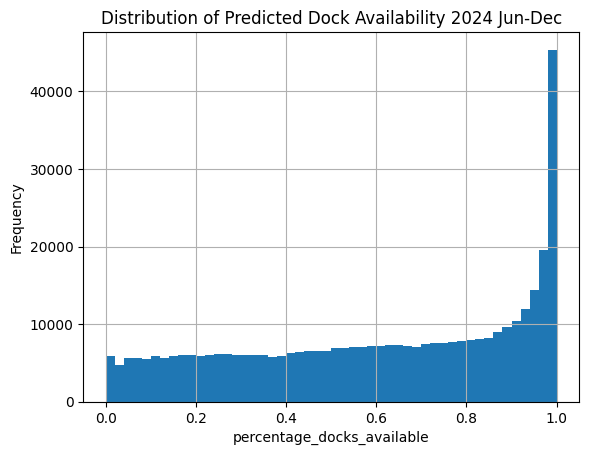

In [152]:
display(submission_df)

print(submission_df)

import matplotlib.pyplot as plt

plt.hist(submission_df['percentage_docks_available'], bins=50)
plt.title("Distribution of Predicted Dock Availability 2024 Jun-Dec")
plt.xlabel("percentage_docks_available")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


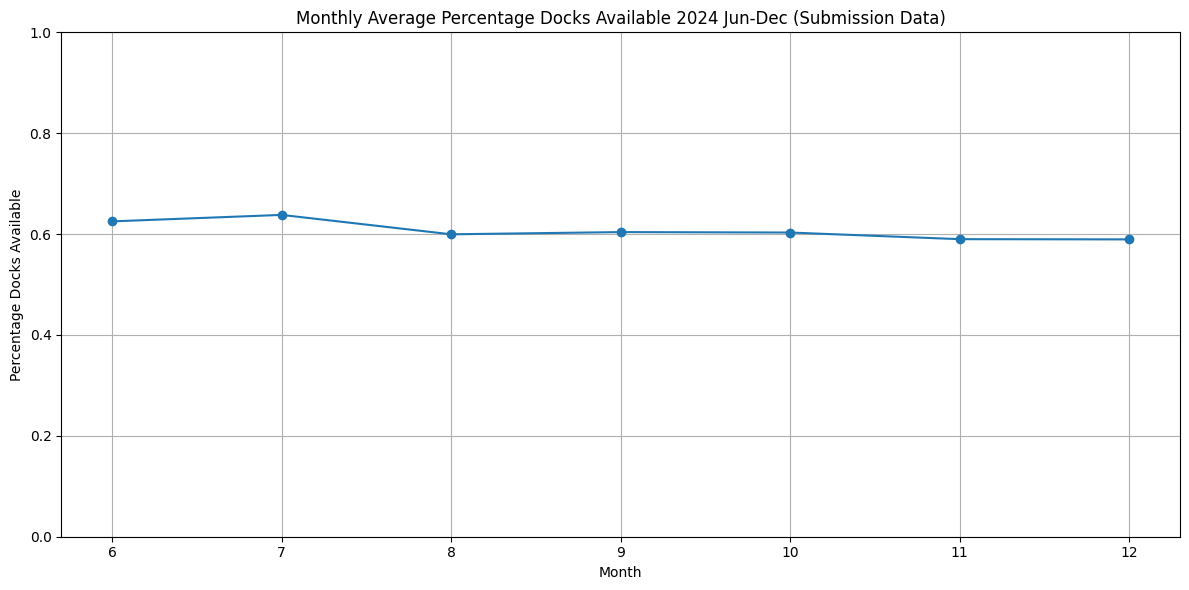

In [166]:
# Group by month only
monthly_avg = submission_df.groupby('month')['percentage_docks_available'].mean().reset_index()

# Optional: sort months if not already sorted
monthly_avg = monthly_avg.sort_values('month')

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg['month'], monthly_avg['percentage_docks_available'], marker='o')
plt.xticks(monthly_avg['month'])
plt.ylim(0, 1)
plt.title("Monthly Average Percentage Docks Available 2024 Jun-Dec (Submission Data)")
plt.xlabel("Month")
plt.ylabel("Percentage Docks Available")
plt.grid(True)
plt.tight_layout()
plt.show()


The submission should be a CSV file with 401511 rows and a header.

In [153]:
import pandas as pd


# Save final submission file
final_submission = submission_df[['index', 'percentage_docks_available']]

# Check shape and header
print(f"Submission shape: {final_submission.shape}")
print("Submission columns:", list(final_submission.columns))

# Check for correct number of rows
expected_rows = 401511
actual_rows = final_submission.shape[0]

if actual_rows == expected_rows:
    print("✅ Correct number of rows.")
else:
    print(f"⚠️ Incorrect number of rows. Expected: {expected_rows}, Got: {actual_rows}")

# Preview submission
print(final_submission.head())

final_submission.to_csv("submission_2025.csv", index=False)

print("✅ Submission file generated successfully.")


Submission shape: (401511, 2)
Submission columns: ['index', 'percentage_docks_available']
✅ Correct number of rows.
   index  percentage_docks_available
0      0                    0.323297
1      1                    0.459513
2      2                    0.776674
3      3                    0.853051
4      4                    0.766854
✅ Submission file generated successfully.


Improvement Ideas:

1. remove all stations above 496 which are not in meta
2. test with more features or engineer new which we could create also in meta on the fly ,eg averages of ctx-1 etc
3. needed think about the weather again
4. add NN or LSTM
5. why the erorr is so low
6. check for data leak
7. upload to github
8. clean code